koulutus optimoijalla: Adam
 koulutuskiekka 1/5 - lossi: 0.5185
 koulutuskiekka 2/5 - lossi: 0.3893
 koulutuskiekka 3/5 - lossi: 0.3505
 koulutuskiekka 4/5 - lossi: 0.3260
 koulutuskiekka 5/5 - lossi: 0.3036
koulutus optimoijalla: SGD
 koulutuskiekka 1/5 - lossi: 1.7886
 koulutuskiekka 2/5 - lossi: 1.1437
 koulutuskiekka 3/5 - lossi: 0.9024
 koulutuskiekka 4/5 - lossi: 0.7905
 koulutuskiekka 5/5 - lossi: 0.7274


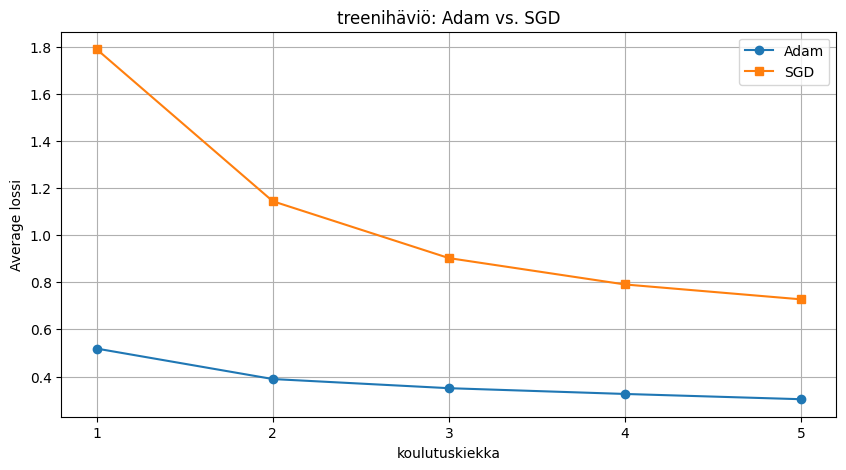

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# 1. Data loading and preparation
# Hint: Use transforms.ToTensor and Normalize
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
full_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_dataset, test_dataset = random_split(full_dataset, [50000, 10000])

# DataLoader: Remember, this is efficient for larger datasets
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

##opiskelijan osuus ---->

class FashionClassifier(nn.Module):
    def __init__(self):
        super(FashionClassifier, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10) 

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# tehdään koulutusfunktio jotta voidaan ajaa mollemmilla optimizereilla.
def train_with_optimizer(optimizer_name, epochs=5):
    # luodaan uus malli ja weightit nollataan joka kerta
    model = FashionClassifier()
    criterion = nn.CrossEntropyLoss()
    
    # valitaan optimizer param. perusteella.
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    else:
        optimizer = optim.SGD(model.parameters(), lr=0.001)
        
    loss_history = []
    
    print(f"koulutus optimoijalla: {optimizer_name}")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            optimizer.zero_grad()           
            outputs = model(images)         
            loss = criterion(outputs, labels) 
            loss.backward()                 
            optimizer.step()                
            
            running_loss += loss.item()
            
        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f" koulutuskiekka {epoch+1}/{epochs} - lossi: {avg_loss:.4f}")
        
    return loss_history

# Suoritetaan kokeilut
loss_adam = train_with_optimizer('Adam', epochs=5)
loss_sgd = train_with_optimizer('SGD', epochs=5)

# tehdään plotti
plt.figure(figsize=(10, 5))
plt.plot(loss_adam, label='Adam', marker='o')
plt.plot(loss_sgd, label='SGD', marker='s')
plt.title('treenihäviö: Adam vs. SGD')
plt.xlabel('koulutuskiekka')
plt.ylabel('Average lossi')
plt.xticks(range(5), [1, 2, 3, 4, 5])
plt.legend()
plt.grid(True)
plt.show()